In [10]:
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array

from sklearn.metrics import(
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [11]:
model = tf.keras.models.load_model("mango_leaf_model_v3_final.keras")

print("Model loaded Succesfully")

test_folder = r"D:\Ai Models\GoogleTestImages"

Model loaded Succesfully


In [12]:
class_names = [
    "Anthracnose",
    "Bacterial Canker",
    "Cutting Weevil",
    "Die Back",
    "Gall Midege",
    "Healthy",
    "Powdery Mildew",
    "Sooty Mould"
]

#CNN only predict numbers


 GOOGLE IMAGE EVALUATION REPORT 
Total Images Tested      : 32
Correct Predictions      : 11
Incorrect Predictions    : 21
Overall Accuracy         : 34.38%
Average Confidence       : 72.67%

PER CLASS ACCURACY

              Class  Tested  Correct  Incorrect  Accuracy (%)
0       Anthracnose       5        1          4     20.000000
1  Bacterial Canker       2        0          2      0.000000
2    Cutting Weevil       3        1          2     33.333333
3          Die Back       3        0          3      0.000000
4       Gall Midege       5        0          5      0.000000
5           Healthy       7        7          0    100.000000
6    Powdery Mildew       3        2          1     66.666667
7       Sooty Mould       4        0          4      0.000000
true_labels 32
predicted_labels 32
['Anthracnose', 'Anthracnose', 'Anthracnose', 'Anthracnose', 'Anthracnose']
['Powdery Mildew', 'Sooty Mould', 'Anthracnose', 'Powdery Mildew', 'Sooty Mould']
(32, 4)

CLASSIFICATION REPORT

     

C:\Users\udnrm\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\udnrm\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\udnrm\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

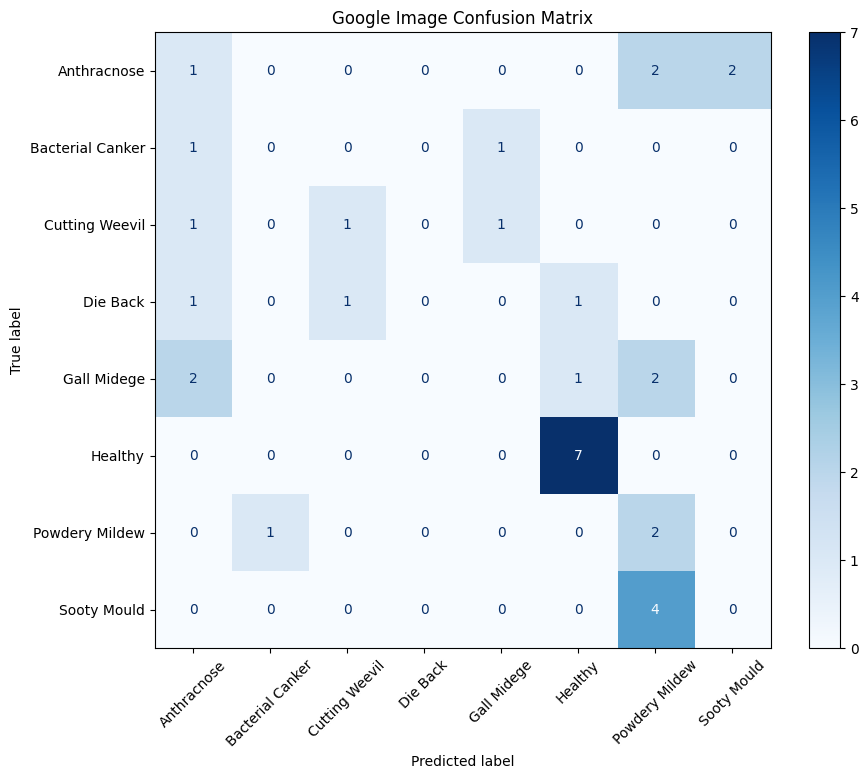


INCORRECT PREDICTIONS

                      Image            Actual         Predicted  \
0        anthracnose_01.jpg       Anthracnose    Powdery Mildew   
1        anthracnose_02.jpg       Anthracnose       Sooty Mould   
3        anthracnose_04.jpg       Anthracnose    Powdery Mildew   
4        anthracnose_05.jpg       Anthracnose       Sooty Mould   
5   Bacterial_Canker_01.jpg  Bacterial Canker       Anthracnose   
6   Bacterial_Canker_02.jpg  Bacterial Canker       Gall Midege   
7     cutting weevil_01.jpg    Cutting Weevil       Gall Midege   
8     cutting weevil_03.jpg    Cutting Weevil       Anthracnose   
10          die_back-02.jpg          Die Back    Cutting Weevil   
11          die_back-03.jpg          Die Back           Healthy   
12          die_back_01.jpg          Die Back       Anthracnose   
13        gall_midge_01.jpg       Gall Midege    Powdery Mildew   
14        gall_midge_02.jpg       Gall Midege       Anthracnose   
15        gall_midge_03.jpg       Gall

In [13]:
results = []

true_labels = []
predicted_labels = []
confidences = []


for actual_class in class_names:

    class_folder = os.path.join(test_folder, actual_class)

    if not os.path.exists(class_folder):

        continue

    for filename in os.listdir(class_folder):

      if filename.lower().endswith((".jpg", ".png", ".jpeg")):
  
        image_path = os.path.join(class_folder, filename)

        img = load_img(image_path, target_size=(260,260))

        img_array = img_to_array(img)
   
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array, verbose=0)

        predicted_index = np.argmax(prediction)
        predicted_class = class_names[predicted_index]
        confidence = np.max(prediction)
        true_labels.append(actual_class)
        predicted_labels.append(predicted_class)
        confidences.append(confidence)

        
        results.append({
         "Image": filename,
          "Actual": actual_class,
          "Predicted": predicted_class,
          "Confidence (%)": confidence*100
        })

# Convert to DataFrame
df = pd.DataFrame(results)


# Overall Accuracy
correct = (df["Actual"] == df["Predicted"]).sum()

total = len(df)

accuracy = correct / total * 100

print("="*60)
print(" GOOGLE IMAGE EVALUATION REPORT ")
print("="*60)

print(f"Total Images Tested      : {total}")
print(f"Correct Predictions      : {correct}")
print(f"Incorrect Predictions    : {total-correct}")
print(f"Overall Accuracy         : {accuracy:.2f}%")
print(f"Average Confidence       : {df['Confidence (%)'].mean():.2f}%")

print("="*60)


# Per Class Accuracy
print("\nPER CLASS ACCURACY\n")

summary = []

for cls in class_names:

    class_data = df[df["Actual"] == cls]

    tested = len(class_data)

    correct = (class_data["Actual"] == class_data["Predicted"]).sum()

    class_accuracy = correct/tested*100

    summary.append([
        cls,
        tested,
        correct,
        tested-correct,
        class_accuracy
    ])

summary_df = pd.DataFrame(
    summary,
    columns=[
        "Class",
        "Tested",
        "Correct",
        "Incorrect",
        "Accuracy (%)"
    ]
)

print(summary_df)


print("true_labels", len(true_labels))
print("predicted_labels", len(predicted_labels))

print(true_labels[:5])
print(predicted_labels[:5])
print(df.shape)

# Classification Report

print("\nCLASSIFICATION REPORT\n")

print(classification_report(
   true_labels,
   predicted_labels,
))


# Confusion Matrix
cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=class_names
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,8))

disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45
)

plt.title("Google Image Confusion Matrix")

plt.show()


# Show Incorrect Predictions
print("\nINCORRECT PREDICTIONS\n")

incorrect = df[df["Actual"] != df["Predicted"]]

print(incorrect)



In [14]:
"""for filename in os.listdir(test_folder):

 if filename.lower().endswith((".jpg", ".png", ".jpeg")):
  
   image_path = os.path.join(test_folder, filename)

   img = load_img(image_path, target_size=(224,224))

   img_array = img_to_array(img)
   
   img_array = np.expand_dims(img_array, axis=0)

   prediction = model.predict(img_array, verbose=0)

   predicted_index = np.argmax(prediction)
   predicted_class = class_names[predicted_index]
   confidence = np.max(prediction)
   

   print("-"*50)
   print("Image : ", filename)
   print("prediction: ", predicted_class)
   print(f"confidence:{confidence*100:.2f}%")  """



'for filename in os.listdir(test_folder):\n\n if filename.lower().endswith((".jpg", ".png", ".jpeg")):\n\n   image_path = os.path.join(test_folder, filename)\n\n   img = load_img(image_path, target_size=(224,224))\n\n   img_array = img_to_array(img)\n\n   img_array = np.expand_dims(img_array, axis=0)\n\n   prediction = model.predict(img_array, verbose=0)\n\n   predicted_index = np.argmax(prediction)\n   predicted_class = class_names[predicted_index]\n   confidence = np.max(prediction)\n\n\n   print("-"*50)\n   print("Image : ", filename)\n   print("prediction: ", predicted_class)\n   print(f"confidence:{confidence*100:.2f}%")  '